# 03 — Construção e seleção de features de risco

**CONTEXTO**: com as features v1 (`pct_*` sobre o total de hits
beta-lactâmicos), o KMeans k=2 separava *Acinetobacter* (+ *Serratia*) do resto e o k=4 separava
*Klebsiella* de *E. coli* — ou seja, os clusters reencontravam a espécie e não o risco. Isso porque as features misturavam genes intrínsecos (OXA-51 em *A. baumannii*, SHV-1/11 em
*K. pneumoniae*, EC em *E. coli*, efluxo/porina/PBP em todos) com genes adquiridos.

Nesse contexto, reinicei a montagem das features com `src/features_risco.py` e funções testadas no `notebooks/02_classes_bl.ipynb`.

In [1]:
import itertools
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from notebooks.src.features_risco import (
    CatalogoBetaLactamase, INTRINSECOS_POR_GENERO, anotar_resistoma_risco, build_features_risco,
)

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Dados

In [2]:
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
metadata = metadata[metadata["Species"] != "Mycobacterium tuberculosis"]
# o resistoma de *M. tuberculosis* é quase todo mutação cromossômica
# sobra so gram negativos

resistome = pd.read_csv(
    RAIZ / "data/raw/resistome_recorte.csv",
    usecols=["sample_id", "gene_clean", "amr_gene_family", "model_type", "contig_type"],
)
resistome = resistome[resistome["sample_id"].isin(metadata.index)]
print(f"{len(metadata)} genomas | {len(resistome)} hits do RGI")
metadata["Species"].value_counts().head(10)

2226 genomas | 105812 hits do RGI


Species
Klebsiella pneumoniae         1056
Escherichia coli               529
Acinetobacter baumannii        413
Enterobacter hormaechei         37
Klebsiella quasipneumoniae      36
Serratia marcescens             35
Klebsiella aerogenes            22
Proteus mirabilis               20
Klebsiella variicola            13
Klebsiella sp.                   8
Name: count, dtype: int64

## 2. Construção das features

In [3]:
pd.Series({k: ", ".join(v) for k, v in INTRINSECOS_POR_GENERO.items()}, name="regex intrínseco").to_frame()

,regex intrínseco
Acinetobacter,"^OXA-51-like$, ^ADC-, ^ANT\(3''\)-IIa$"
Klebsiella,"^SHV-, ^OKP-, ^LEN-, ^OXY-, ^Fos[Aa][25678](?:\.\d+)?$"
Klebsiella aerogenes,"^CMY-190$, ^Fos[Aa][25678](?:\.\d+)?$"
Escherichia,"^EC-, ^Ecol_ampC_BLA$"
Enterobacter,"^ACT-, ^MIR-, ^CMH-, ^Fos[Aa][25678](?:\.\d+)?$"
Serratia,"^SRT-, ^SST-, ^AAC\(6'\)-Ic$, ^Fos[Aa][25678](?:\.\d+)?$, ^tet\(41\)$"
Citrobacter,"^CMY-, ^CFE-, ^CKO-"
Morganella,"^DHA-, ^MOR-"
Providencia,^AAC\(2'\)-I
Proteus,"^tet\(J\)$, ^Fos[Aa]8$"


In [3]:
catalogo = CatalogoBetaLactamase(RAIZ / "data/raw/refgenes.tsv")
anotado = anotar_resistoma_risco(resistome, metadata["Species"], catalogo)

print("Genes removidos como intrínsecos (nº de genomas):")
print(anotado[anotado["intrinseco"]].groupby("gene_clean")["sample_id"].nunique()
      .sort_values(ascending=False).head(15).to_string())

Genes removidos como intrínsecos (nº de genomas):
gene_clean
FosA6            946
SHV-11           762
ANT(3'')-IIa     410
OXA-51-like      409
SHV-1            157
EC-14            141
ADC-182          133
ADC-30           121
Ecol_ampC_BLA    115
EC-5              82
SHV-28            70
EC-8              61
FosA8             49
FosA2             48
AAC(6')-Ic        38


### 2.2 Função da beta-lactamase (catálogo NCBI AMRFinderPlus)

`product_name` do refgenes: 
- `carbapenem-hydrolyzing` → carbapenemase de serina (classe A/D)
- `metallo-beta-lactamase` → MBL (classe B)
- `extended-spectrum` → ESBL (classe A)
- `ampc` -> AmpC (classe C)
- resto → espectro estreito

"Substitui" `drug_class` do CARD por esse.

In [5]:
(anotado[anotado["categoria"].notna()]
 .groupby("categoria")["gene_clean"]
 .agg(lambda s: ", ".join(f"{g} ({n})" for g, n in s.value_counts().head(6).items())))

categoria
aminoglicosideo_ame          APH(6)-Id (869), APH(3'')-Ib (846), AAC(6')-Ib10 (815), APH(3')-Ia (604), aadA (558), aadA2 (493)
aminoglicosideo_metilase                                      rmtB (149), armA (136), rmtG (12), rmtD2 (2), rmtF (2), rmtD (1)
bl_ampc                                             CMY-181 (52), CMY-2 (14), DHA-1 (7), CMY-174 (1), CMY-176 (1), CMY-189 (1)
bl_carbapenemase            KPC-2 (822), OXA-23-like (310), NDM-1 (214), OXA-143-like (42), OXA-24-like (38), OXA-58-like (11)
bl_esbl                               CTX-M-15 (618), CTX-M-2 (167), CTX-M-14 (159), CTX-M-8 (68), CTX-M-55 (23), CTX-M-9 (14)
bl_estreito                       TEM-1 (1064), OXA-1-like (557), OXA-2-like (142), OXA-9-like (137), LAP-2 (82), TEM-239 (58)
fenicol                                              catA1 (442), floR (219), cmlA9 (146), catB8 (119), catB3 (68), cmlA4 (26)
fosfomicina                                                                                          

In [4]:
features_todas = build_features_risco(anotado, metadata.index)
CANDIDATAS = list(features_todas.columns)
features_todas.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
has_carbapenemase,2226.0,0.64,0.48,0.0,0.00,1.00,1.00,1.0
has_mbl,2226.0,0.11,0.31,0.0,0.00,0.00,0.00,1.0
has_carbapenemase_serina,2226.0,0.57,0.50,0.0,0.00,1.00,1.00,1.0
n_carbapenemases,2226.0,0.68,0.55,0.0,0.00,1.00,1.00,2.0
has_esbl,2226.0,0.48,0.50,0.0,0.00,0.00,1.00,1.0
has_ampc_adquirida,2226.0,0.04,0.18,0.0,0.00,0.00,0.00,1.0
n_bl_adquiridas,2226.0,2.18,1.46,0.0,1.00,2.00,3.00,7.0
has_16s_metilase,2226.0,0.14,0.34,0.0,0.00,0.00,0.00,1.0
n_ame,2226.0,2.65,1.77,0.0,1.00,3.00,4.00,8.0
has_mcr,2226.0,0.03,0.17,0.0,0.00,0.00,0.00,1.0


### 2.3 Sanidade: as espécies ficaram mais parecidas?

Na v1, `pct_BD_carbapenemase` era alto em *A. baumannii* por causa da OXA-51 intrínseca. Agora
`has_carbapenemase` compara carbapenemase ADQUIRIDA: OXA-23/24/143 em *A. baumannii* e KPC/NDM em
*K. pneumoniae* entram no mesmo eixo.

In [5]:
especie = metadata["Species"].where(metadata["Species"].map(metadata["Species"].value_counts()) >= 20, "outras")
features_todas.groupby(especie).mean().T.round(2)

Species,Acinetobacter baumannii,Enterobacter hormaechei,Escherichia coli,Klebsiella aerogenes,Klebsiella pneumoniae,Klebsiella quasipneumoniae,Proteus mirabilis,Serratia marcescens,outras
has_carbapenemase,0.96,0.84,0.06,0.50,0.80,0.92,0.15,0.71,0.55
has_mbl,0.08,0.38,0.03,0.09,0.11,0.78,0.10,0.06,0.32
has_carbapenemase_serina,0.95,0.51,0.04,0.41,0.73,0.17,0.10,0.66,0.24
n_carbapenemases,1.06,0.89,0.06,0.50,0.84,0.94,0.20,0.71,0.56
has_esbl,0.01,0.73,0.32,0.55,0.75,0.72,0.35,0.23,0.42
has_ampc_adquirida,0.00,0.14,0.13,0.00,0.00,0.00,0.05,0.00,0.04
n_bl_adquiridas,1.42,3.16,1.10,2.36,3.01,3.03,1.15,1.40,1.88
has_16s_metilase,0.31,0.08,0.01,0.05,0.16,0.00,0.00,0.00,0.01
n_ame,3.39,3.84,1.57,2.00,2.95,2.53,1.90,2.20,2.09
has_mcr,0.00,0.27,0.09,0.00,0.00,0.03,0.00,0.00,0.04


## 3. Split treino / validação / teste

70/20/10, **estratificado por espécie** (espécies com < 20 genomas agrupadas em "outras"). Sem a
estratificação, *Serratia*/*Enterobacter* (35-40 genomas) podem quase sumir da validação ou do teste.
A coluna `Species` vai junto no CSV **só para diagnóstico**: ela não entra como feature.

In [6]:
df = features_todas.join(metadata[["Species"]])
estrato = especie.loc[df.index]

df_train, df_temp = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE, stratify=estrato)
df_valid, df_test = train_test_split(
    df_temp, test_size=1 / 3, random_state=RANDOM_STATE, stratify=estrato.loc[df_temp.index]
)
print(f"treino: {len(df_train)} | validação: {len(df_valid)} | teste: {len(df_test)}")

pd.concat({"treino": df_train[CANDIDATAS].mean(), "validação": df_valid[CANDIDATAS].mean(),
           "teste": df_test[CANDIDATAS].mean()}, axis=1).round(3)

treino: 1558 | validação: 445 | teste: 223


,treino,validação,teste
has_carbapenemase,0.644,0.622,0.641
has_mbl,0.116,0.074,0.121
has_carbapenemase_serina,0.567,0.573,0.543
n_carbapenemases,0.687,0.658,0.673
has_esbl,0.485,0.490,0.466
has_ampc_adquirida,0.036,0.027,0.045
n_bl_adquiridas,2.167,2.196,2.197
has_16s_metilase,0.137,0.124,0.148
n_ame,2.655,2.622,2.686
has_mcr,0.025,0.036,0.045


In [7]:
pasta = RAIZ / "data/processed/df_estruturada"
pasta.mkdir(parents=True, exist_ok=True)
df_train.to_csv(pasta / "df_train_risco.csv")
df_valid.to_csv(pasta / "df_valid_risco.csv")
df_test.to_csv(pasta / "df_test_risco.csv")
print("Salvos: df_train_risco.csv, df_valid_risco.csv, df_test_risco.csv")

Salvos: df_train_risco.csv, df_valid_risco.csv, df_test_risco.csv


## 4. Filtros (só no treino)

**Prevalência**: feature binária presente em < 5% do treino não sustenta cluster próprio e, depois
do `StandardScaler`, os poucos genomas com valor 1 viram outliers.

In [10]:
X_tr = df_train[CANDIDATAS]
esp_tr = estrato.loc[df_train.index]


def eta2(x, grupos):
    media = x.mean()
    entre = sum(len(g) * (g.mean() - media) ** 2 for _, g in x.groupby(grupos))
    total = ((x - media) ** 2).sum()
    return entre / total if total > 0 else np.nan


binarias = [c for c in CANDIDATAS if set(X_tr[c].unique()) <= {0, 1}]
diag = pd.DataFrame({
    "tipo": ["binária" if c in binarias else "contínua/contagem" for c in CANDIDATAS],
    "frac_nao_zero": [(X_tr[c] > 0).mean() for c in CANDIDATAS],
    "eta2_especie": [eta2(X_tr[c], esp_tr) for c in CANDIDATAS],
}, index=CANDIDATAS).round(3)
diag

,tipo,frac_nao_zero,eta2_especie
has_carbapenemase,binária,0.644,0.502
has_mbl,binária,0.116,0.128
has_carbapenemase_serina,binária,0.567,0.473
n_carbapenemases,contínua/contagem,0.644,0.451
has_esbl,binária,0.485,0.339
has_ampc_adquirida,binária,0.036,0.101
n_bl_adquiridas,contínua/contagem,0.872,0.352
has_16s_metilase,binária,0.137,0.094
n_ame,contínua/contagem,0.818,0.150
has_mcr,binária,0.025,0.078


In [13]:
PREV_MIN = 0.05
raras = diag.query("tipo == 'binária' and frac_nao_zero < @PREV_MIN").index.tolist()
print(f"Saem por prevalência < {PREV_MIN:.0%}: {raras}")
restantes = [c for c in CANDIDATAS if c not in raras]

Saem por prevalência < 5%: ['has_ampc_adquirida', 'has_mcr']


## 5. Redundância (Spearman, só treino)

Spearman em vez de Pearson: as contagens são assimétricas e várias colunas são binárias. Os pares
com p > 0,8 carregam praticamente a mesma informação. Em cada par, fica a feature mais
interpretável ou mais geral:

- `has_carbapenemase` × `n_carbapenemases` × `has_carbapenemase_serina`: fica `has_carbapenemase`.
- `n_ame` × `n_genes_adquiridos` × `n_classes_adquiridas`: `n_ame` sai, porque é um componente dos
  outros dois. 

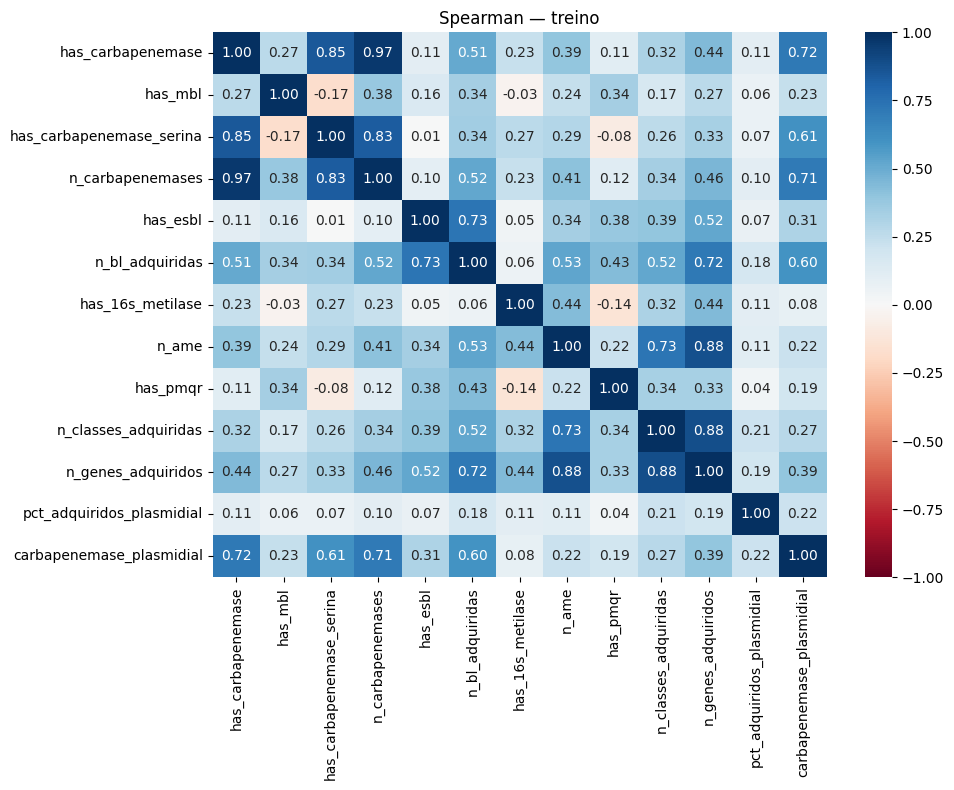

In [15]:
corr = X_tr[restantes].corr("spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-1, vmax=1)
plt.title("Spearman — treino")
plt.tight_layout()
plt.show()

In [18]:
pares_altos = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
               .loc[lambda s: s.abs() > 0.8].sort_values(ascending=False))
pares_altos

has_carbapenemase         n_carbapenemases            0.965958
n_classes_adquiridas      n_genes_adquiridos          0.883880
n_ame                     n_genes_adquiridos          0.878154
has_carbapenemase         has_carbapenemase_serina    0.849604
has_carbapenemase_serina  n_carbapenemases            0.834080
dtype: float64

In [19]:
REDUNDANTES = ["n_carbapenemases", "has_carbapenemase_serina", "n_ame"]
ALTERNATIVAS = ("n_genes_adquiridos", "n_classes_adquiridas")   # nunca juntas
CANDIDATAS_FINAIS = [c for c in restantes if c not in REDUNDANTES]
print(CANDIDATAS_FINAIS)

['has_carbapenemase', 'has_mbl', 'has_esbl', 'n_bl_adquiridas', 'has_16s_metilase', 'has_pmqr', 'n_classes_adquiridas', 'n_genes_adquiridos', 'pct_adquiridos_plasmidial', 'carbapenemase_plasmidial']


## 6. Clsutering Bivariado para `feature selection`:
Para cada par de colunas, roda o grid do KMeans com CV (Silhouette) e plota o scatter.

**PROBLEMA (chat)**: num par **binária × binária** só existem 4 pontos distintos no plano. O
KMeans com k=4 coloca um centróide em cada ponto e o silhouette vai para ~1,0 de forma trivial.
Então o ranking bivariado só é lido para pares que tenham pelo menos uma contínua/contagem.

In [20]:
from notebooks.src.clustering import Clustering

linhas = []
for a, b in itertools.combinations(CANDIDATAS_FINAIS, 2):
    if a in binarias and b in binarias:
        continue
    _, Xs, (ss, chs, dbs), grid = Clustering([a, b], df_train, "kmeans").cross_validation(print_metricas=False)
    melhor = grid.nlargest(1, "mean_score").iloc[0]
    linhas.append({"c1": a, 
                   "c2": b, 
                   "k": int(melhor["n_clusters"]), 
                   "silhouette_cv": melhor["mean_score"],
                   "silhouette_fit": ss, 
                   "calinski_harabasz_fit": chs})
bivariado = pd.DataFrame(linhas).sort_values("silhouette_cv", ascending=False).round(3)
bivariado

,c1,c2,k,silhouette_cv,silhouette_fit,calinski_harabasz_fit
4,has_mbl,n_bl_adquiridas,8,0.959,0.938,18666.989
12,n_bl_adquiridas,has_16s_metilase,8,0.956,0.955,17629.551
8,has_esbl,n_bl_adquiridas,8,0.946,0.945,24408.003
0,has_carbapenemase,n_bl_adquiridas,8,0.929,0.903,14937.128
13,n_bl_adquiridas,has_pmqr,8,0.913,0.906,11274.215
17,n_bl_adquiridas,carbapenemase_plasmidial,8,0.900,0.901,11266.771
18,has_16s_metilase,n_classes_adquiridas,8,0.867,0.895,15512.039
5,has_mbl,n_classes_adquiridas,8,0.831,0.853,9830.737
21,has_pmqr,n_classes_adquiridas,8,0.798,0.801,10107.470
1,has_carbapenemase,n_classes_adquiridas,8,0.752,0.726,7612.753


In [22]:
por_feature = pd.concat([bivariado[["c1", "silhouette_cv"]].rename(columns={"c1": "f"}),
                         bivariado[["c2", "silhouette_cv"]].rename(columns={"c2": "f"})])

por_feature.head()

,f,silhouette_cv
4,has_mbl,0.959
12,n_bl_adquiridas,0.956
8,has_esbl,0.946
0,has_carbapenemase,0.929
13,n_bl_adquiridas,0.913


In [24]:
por_feature.groupby("f")["silhouette_cv"].agg(["mean", "max", "count"]).sort_values("mean", ascending=False).round(3)

,mean,max,count
f,,,
has_16s_metilase,0.801,0.956,4
n_bl_adquiridas,0.790,0.959,9
has_mbl,0.789,0.959,4
has_pmqr,0.753,0.913,4
has_esbl,0.742,0.946,4
has_carbapenemase,0.742,0.929,4
carbapenemase_plasmidial,0.724,0.900,4
n_classes_adquiridas,0.708,0.867,9
pct_adquiridos_plasmidial,0.634,0.688,9


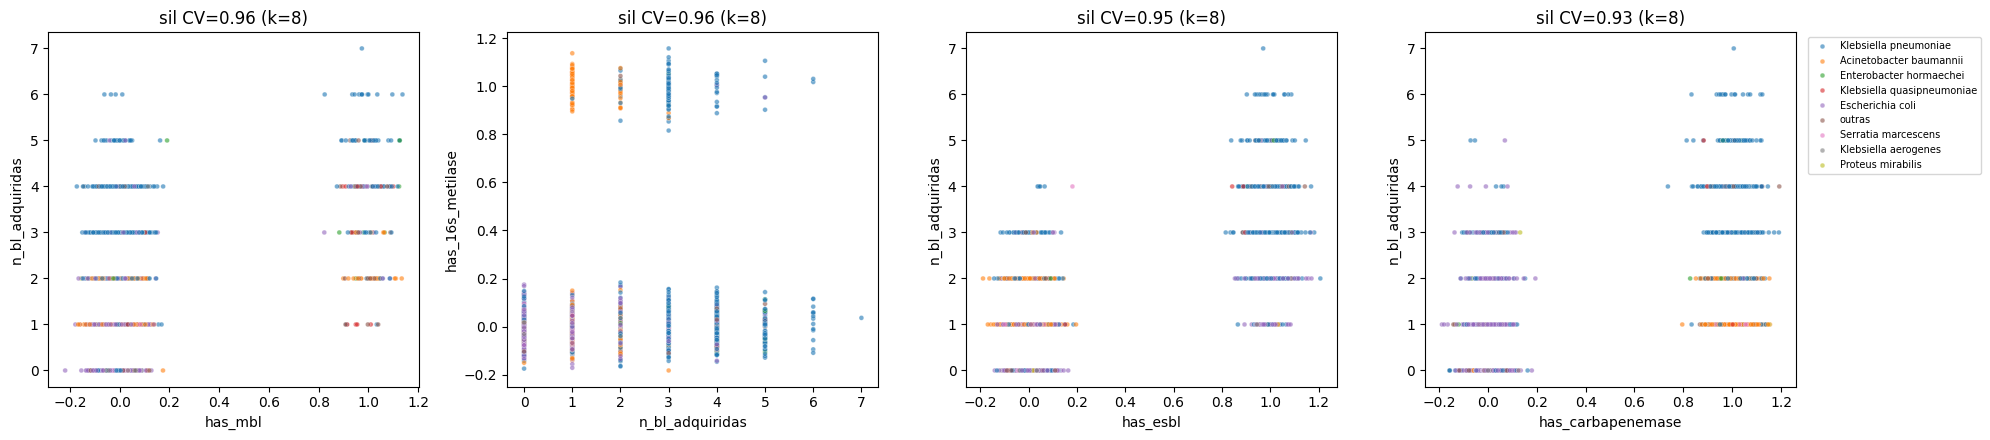

In [16]:
# scatter dos 4 melhores pares (jitter nas binárias pra enxergar densidade)
rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (_, p) in zip(axes, bivariado.head(4).iterrows()):
    x = df_train[p.c1] + (rng.normal(0, 0.06, len(df_train)) if p.c1 in binarias else 0)
    y = df_train[p.c2] + (rng.normal(0, 0.06, len(df_train)) if p.c2 in binarias else 0)
    sns.scatterplot(x=x, y=y, hue=esp_tr.values, s=12, alpha=0.6, ax=ax, legend=(ax is axes[-1]))
    ax.set(xlabel=p.c1, ylabel=p.c2, title=f"sil CV={p.silhouette_cv:.2f} (k={p.k})")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

In [26]:
FEATURES_FINAIS = ['has_carbapenemase',
 'has_mbl',
 'has_esbl',
 'n_bl_adquiridas',
 'has_16s_metilase',
 'carbapenemase_plasmidial']

FEATURES_FINAIS

['has_carbapenemase',
 'has_mbl',
 'has_esbl',
 'n_bl_adquiridas',
 'has_16s_metilase',
 'carbapenemase_plasmidial']

### 7.1 Comparação com as features v1

Mesmo teste nas features v1, no mesmo treino e com o mesmo KMeans: quanto a partição se confunde
com a espécie?

In [29]:
v1 = pd.read_csv(RAIZ / "data/raw/features_v1.csv", index_col=0)
FEATURES_V1 = ["n_beta_lactam_total", "pct_esbl", "pct_A_serino_carbapenemase", "pct_BD_carbapenemase",
               "pct_C_ampc", "pct_nao_hidrolise", "pct_beta_lactam_plasmidial", "n_aminoglicosideo"]
comparacao = []
for nome, base, cols in [("v1", v1.loc[df_train.index], FEATURES_V1), ("risco (final)", df_train, FEATURES_FINAIS)]:
    Xc = StandardScaler().fit_transform(base[cols].fillna(0))
    for k in (2, 4, 5, 6):
        lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xc)
        comparacao.append({"features": nome, "k": k, "silhouette": silhouette_score(Xc, lab),
                           "calinski_harabasz": calinski_harabasz_score(Xc, lab),
                           "ari_especie": adjusted_rand_score(esp_tr, lab)})
pd.DataFrame(comparacao).drop_duplicates(["features", "k"]).round(3)

,features,k,silhouette,calinski_harabasz,ari_especie
0,v1,2,0.454,945.375,0.376
1,v1,4,0.361,858.766,0.581
2,v1,5,0.338,766.221,0.557
3,v1,6,0.361,720.541,0.497
4,risco (final),2,0.377,852.949,0.258
5,risco (final),4,0.480,903.515,0.198
6,risco (final),5,0.532,944.906,0.289
7,risco (final),6,0.602,1271.199,0.205


## 8. Salvando a seleção

In [30]:
saida = {
    "features_finais": FEATURES_FINAIS,
}

(RAIZ / "data/processed/features_selecionadas.json").write_text(json.dumps(saida, indent=2, ensure_ascii=False))
saida

{'features_finais': ['has_carbapenemase',
  'has_mbl',
  'has_esbl',
  'n_bl_adquiridas',
  'has_16s_metilase',
  'carbapenemase_plasmidial']}